In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

SEED = 42

tf.keras.utils.set_random_seed(SEED)

# Ask TensorFlow to use deterministic operations where available.
tf.config.experimental.enable_op_determinism()

print("TensorFlow version:", tf.__version__)
print("Random seed:", SEED)

TensorFlow version: 2.20.0
Random seed: 42


In [ ]:
(x_train_raw, y_train), (x_test_raw, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train_raw.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test_raw.shape)
print("Test labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


In [ ]:
x_train = x_train_raw.astype("float32") / 255.0
x_test = x_test_raw.astype("float32") / 255.0

# MNIST images are grayscale, so the channel dimension is 1.
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print("Processed training images:", x_train.shape)
print("Processed test images:", x_test.shape)

Processed training images: (60000, 28, 28, 1)
Processed test images: (10000, 28, 28, 1)


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, kernel_size=3, activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    tf.keras.layers.Conv2D(64, kernel_size=3, activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=5,
    validation_split=0.1,
    shuffle=True,
    verbose=1,
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 47s 105ms/step - accuracy: 0.9281 - loss: 0.2492 - val_accuracy: 0.9812 - val_loss: 0.0639
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 104ms/step - accuracy: 0.9791 - loss: 0.0672 - val_accuracy: 0.9862 - val_loss: 0.0480
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 105ms/step - accuracy: 0.9854 - loss: 0.0474 - val_accuracy: 0.9875 - val_loss: 0.0404
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 106ms/step - accuracy: 0.9887 - loss: 0.0358 - val_accuracy: 0.9887 - val_loss: 0.0376
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 104ms/step - accuracy: 0.9911 - loss: 0.0286 - val_accuracy: 0.9895 - val_loss: 0.0361


In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4%}")

Test loss:     0.0333
Test accuracy: 98.9300%


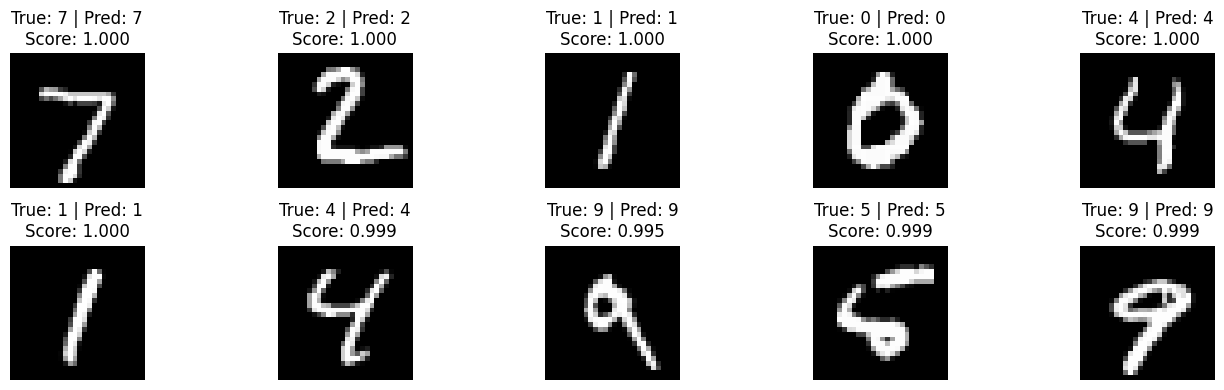

In [ ]:
sample_count = 10
sample_images = x_test[:sample_count]
sample_labels = y_test[:sample_count]

probabilities = model.predict(sample_images, verbose=0)
predicted_labels = np.argmax(probabilities, axis=1)
top_scores = np.max(probabilities, axis=1)

plt.figure(figsize=(14, 4))

for i in range(sample_count):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i].squeeze(), cmap="gray")
    plt.title(
        f"True: {sample_labels[i]} | Pred: {predicted_labels[i]}\n"
        f"Score: {top_scores[i]:.3f}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model.save("mnist_baseline.keras")
print("Saved model to mnist_baseline.keras")

Saved model to mnist_baseline.keras
